# PINNs frente a m&eacute;todos cl&aacute;sicos: resolver una EDP por comparaci&oacute;n

### An&aacute;lisis num&eacute;rico de ecuaciones diferenciales &mdash; cuaderno de clase

Este cuaderno resuelve **un mismo problema de EDP de dos maneras** &mdash; con un m&eacute;todo cl&aacute;sico (diferencias finitas) y con una **red neuronal informada por la f&iacute;sica (PINN)** &mdash; y las compara en **ejecuci&oacute;n** (tiempo, costo) y **precisi&oacute;n** (error). La idea no es vender un m&eacute;todo, sino *aprender por contraste*: ver d&oacute;nde el enfoque cl&aacute;sico es imbatible, d&oacute;nde se rompe, y d&oacute;nde el PINN cambia las reglas del juego.

El recorrido es:

1. El problema y su tipo (una EDP el&iacute;ptica en 1D).
2. El m&eacute;todo cl&aacute;sico: discretizar hasta un sistema lineal disperso.
3. El PINN: reformular la EDP como un problema de optimizaci&oacute;n.
4. **Comparaci&oacute;n cara a cara**: precisi&oacute;n, tiempo y escalamiento del costo.
5. **D&oacute;nde gana el PINN**: un problema *inverso*.
6. Conclusiones.


**C&oacute;mo usarlo.** Ejecute las celdas de arriba hacia abajo (men&uacute; *Entorno de ejecuci&oacute;n &rarr; Ejecutar todas*). En Google Colab, PyTorch ya viene instalado; no hay que instalar nada. El entrenamiento del PINN tarda unos segundos en CPU.

In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

import torch
import torch.nn as nn

# Reproducibilidad (los resultados del PINN varian algo entre corridas)
np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| dispositivo:", device)


PyTorch 2.11.0+cpu | dispositivo: cpu


## 1. El problema y su tipo

Trabajamos con la **ecuaci&oacute;n de Poisson en 1D**, el prototipo de las EDP **el&iacute;pticas** (estados de equilibrio, sin variable temporal):

$$-u''(x) = f(x), \qquad x\in(0,1), \qquad u(0)=u(1)=0.$$

Para poder *medir* el error, usamos una **soluci&oacute;n fabricada**: elegimos de antemano

$$u^{*}(x) = \sin(\pi x) \quad\Longrightarrow\quad f(x) = \pi^2\sin(\pi x),$$

de modo que conocemos la respuesta exacta y podemos comparar cada m&eacute;todo contra ella.


In [4]:
# Datos del problema (versiones NumPy, para el metodo clasico y las graficas)
def f_np(x):        return (np.pi**2) * np.sin(np.pi * x)   # termino fuente
def u_exact(x):     return np.sin(np.pi * x)                # solucion exacta

def rel_L2(u_num, u_ref):
    return np.sqrt(np.mean((u_num - u_ref)**2)) / np.sqrt(np.mean(u_ref**2))


## 2. El m&eacute;todo cl&aacute;sico: diferencias finitas (FDM)

La idea del paradigma cl&aacute;sico es **discretizar**: sobre una malla regular $x_i = ih$, $h=1/N$, sustituimos la segunda derivada por el esquema de tres puntos

$$u''(x_i) \approx \frac{u_{i-1}-2u_i+u_{i+1}}{h^2}.$$

Imponer la ecuaci&oacute;n en cada nodo interior convierte la EDP en un **sistema lineal** $A\,u = b$, donde $A$ es **dispersa, sim&eacute;trica y definida positiva** (tridiagonal en 1D). Lo resolvemos directamente. El error de este esquema decae como $O(h^2)$.


FDM con N = 80  ->  79 grados de libertad
  error L2 relativo = 1.285e-04
  tiempo de resolucion = 4.327 ms


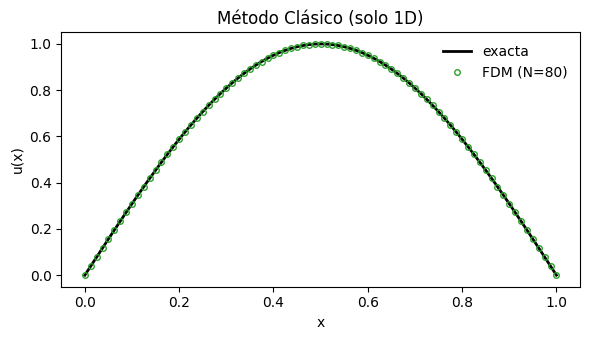


En dimensión d=10 con N=10, la malla tendría 10,000,000,000 puntos
Método clásico inviable. Se usará PINN.


In [5]:
def fdm_solve(N):
    """
    Resuelve -u'' = f en (0,1) con u(0)=u(1)=0 por diferencias finitas.

    NOTA: Este método SOLO funciona en 1D. En alta dimensión (d>=10),
    es inviable por la maldición de la dimensionalidad (N^d puntos).
    """
    h  = 1.0 / N
    x  = np.linspace(0.0, 1.0, N + 1)
    xi = x[1:-1]
    main = (2.0 / h**2) * np.ones(N - 1)
    off  = (-1.0 / h**2) * np.ones(N - 2)
    A = diags([off, main, off], offsets=[-1, 0, 1], format="csr")
    b = f_np(xi)
    t0 = time.perf_counter()
    u_int = spsolve(A, b)
    t_fdm = time.perf_counter() - t0
    u = np.zeros(N + 1)
    u[1:-1] = u_int
    return x, u, t_fdm

# Parámetros para 1D (referencia)
N_fdm = 80
x_fdm, u_fdm, time_fdm = fdm_solve(N_fdm)
dof_fdm = N_fdm - 1
relL2_fdm = rel_L2(u_fdm, u_exact(x_fdm))

print(f"FDM con N = {N_fdm}  ->  {dof_fdm} grados de libertad")
print(f"  error L2 relativo = {relL2_fdm:.3e}")
print(f"  tiempo de resolucion = {time_fdm*1e3:.3f} ms")

# Gráfica
plt.figure(figsize=(6,3.5))
xx = np.linspace(0,1,400)
plt.plot(xx, u_exact(xx), 'k-', lw=2, label='exacta')
plt.plot(x_fdm, u_fdm, 'o', ms=4, mfc='none', color='tab:green', label=f'FDM (N={N_fdm})')
plt.xlabel('x'); plt.ylabel('u(x)')
plt.title('Método Clásico (solo 1D)')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Mostrar por qué no funciona en alta dimensión
d = 10
N = 10
puntos_malla = N ** d
print(f"\nEn dimensión d={d} con N={N}, la malla tendría {puntos_malla:,} puntos")
print("Método clásico inviable. Se usará PINN.")

## 3. El PINN: reformular la EDP como optimizaci&oacute;n

El PINN cambia de estrategia: en lugar de discretizar, **parametriza la soluci&oacute;n** con una red neuronal $\tilde u(x;\theta)$ (un perceptr&oacute;n multicapa con activaci&oacute;n $\tanh$) y busca los par&aacute;metros $\theta$ que minimizan una **p&eacute;rdida informada por la f&iacute;sica**. Para nuestro problema el&iacute;ptico:

$$\mathcal{L}(\theta)=\underbrace{\frac{1}{N_f}\sum_{i}\bigl|-\tilde u''(x_f^i;\theta)-f(x_f^i)\bigr|^2}_{\text{residuo de la EDP } \mathcal{L}_f}\; +\; \lambda_b\underbrace{\bigl(\tilde u(0)^2+\tilde u(1)^2\bigr)}_{\text{condiciones de frontera } \mathcal{L}_b}.$$

La pieza clave es que $\tilde u''$ se calcula por **diferenciaci&oacute;n autom&aacute;tica** (`torch.autograd.grad` aplicado dos veces): no discretizamos el operador ni derivamos f&oacute;rmulas a mano. Resolver la EDP se vuelve

$$\theta^{*} = \arg\min_\theta \mathcal{L}(\theta),$$

que abordamos con el optimizador Adam. La red es **sin malla**: s&oacute;lo necesita *puntos de colocaci&oacute;n* muestreados en el dominio.


In [7]:
# ============================================================
# SECCIÓN 3: El PINN: reformular la EDP como optimización
# (Versión adaptada para alta dimensión, d >= 10)
# ============================================================

class MLP(nn.Module):
    """Perceptron multicapa con activacion tanh.
    Entrada: x de dimension d (vectores en R^d)
    """
    def __init__(self, dim, hidden_layers=4, neurons=100):
        super().__init__()
        layers = [nn.Linear(dim, neurons), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(neurons, neurons))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(neurons, 1))
        self.net = nn.Sequential(*layers)

        # Inicializacion de Xavier
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


def laplacian(net, x):
    """Calcula u y su laplaciano ∇²u usando diferenciacion automatica.

    Args:
        net: red neuronal
        x: tensor (batch, d), requiere_grad=True

    Returns:
        u: tensor (batch, 1)
        lap: tensor (batch, 1) = suma_i ∂²u/∂x_i²
    """
    u = net(x)
    grad_u = torch.autograd.grad(
        u, x, grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]  # forma (batch, d)

    lap = 0.0
    for i in range(x.shape[1]):
        grad_ui = grad_u[:, i:i+1]
        second_deriv = torch.autograd.grad(
            grad_ui, x, grad_outputs=torch.ones_like(grad_ui),
            create_graph=True, retain_graph=True
        )[0][:, i:i+1]
        lap = lap + second_deriv

    return u, lap


def f_torch(x):
    """Termino fuente para la solucion fabricada:
    u(x) = prod_i sin(pi * x_i)
    f(x) = -∇²u = d * pi^2 * prod_i sin(pi * x_i)
    """
    d_dim = x.shape[1]
    prod_sin = torch.prod(torch.sin(np.pi * x), dim=1, keepdim=True)
    return d_dim * (np.pi**2) * prod_sin


# --- preparar puntos (alta dimension, muestreo aleatorio) ---
d = 10  # DIMENSION ESPACIAL (d >= 10)

torch.manual_seed(0)
net = MLP(dim=d).to(device)

# Puntos de colocacion (interior del hipercubo [0,1]^d)
N_f = 5000
x_f = torch.rand(N_f, d, device=device).requires_grad_(True)

# Puntos de frontera (muestreo aleatorio en la frontera del hipercubo)
N_b = 2000
x_b = torch.rand(N_b, d, device=device)
for i in range(N_b):
    coord = np.random.randint(0, d)
    valor = np.random.choice([0.0, 1.0])
    x_b[i, coord] = valor
x_b.requires_grad_(True)

lam_b = 10.0

opt = torch.optim.Adam(net.parameters(), lr=1e-3)
n_steps = 5000

t0 = time.perf_counter()
for it in range(n_steps + 1):
    opt.zero_grad()
    u, lap = laplacian(net, x_f)
    res = -lap - f_torch(x_f)            # residuo de la EDP
    loss_f = (res**2).mean()
    loss_b = (net(x_b)**2).mean()        # condiciones de frontera (u=0)
    loss = loss_f + lam_b * loss_b
    loss.backward()
    opt.step()
    if it % 1000 == 0:
        print(f"  paso {it:5d}  L={loss.item():.3e}  Lf={loss_f.item():.3e}  Lb={loss_b.item():.3e}")
time_pinn = time.perf_counter() - t0
nparams_pinn = sum(p.numel() for p in net.parameters())

print(f"\nPINN en dimensión d={d}: {nparams_pinn} parametros")
print(f"  tiempo de entrenamiento = {time_pinn:.2f} s")

  paso     0  L=1.176e+01  Lf=1.067e+01  Lb=1.089e-01
  paso  1000  L=1.666e-01  Lf=1.532e-01  Lb=1.338e-03
  paso  2000  L=4.411e-02  Lf=3.468e-02  Lb=9.431e-04
  paso  3000  L=2.712e-02  Lf=1.944e-02  Lb=7.682e-04
  paso  4000  L=8.043e-03  Lf=2.040e-03  Lb=6.004e-04
  paso  5000  L=6.831e-03  Lf=1.651e-03  Lb=5.179e-04

PINN en dimensión d=10: 31501 parametros
  tiempo de entrenamiento = 4268.51 s


## 4. Comparaci&oacute;n cara a cara

Superponemos ambas soluciones, miramos el error punto a punto, y resumimos **precisi&oacute;n** y **ejecuci&oacute;n** en una tabla. Para este problema **suave y de baja dimensi&oacute;n**, lo esperable &mdash; y correcto &mdash; es que el m&eacute;todo cl&aacute;sico sea a la vez **m&aacute;s preciso y mucho m&aacute;s r&aacute;pido**. El valor del PINN no est&aacute; aqu&iacute;: lo veremos en las secciones 4.2 y 5.


/tmp/ipykernel_26274/3926694317.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  def u_exact(x):     return np.sin(np.pi * x)                # solucion exacta


  Comparación en dimensión d=10
  Método clásico (FDM):        NO APLICA (inviable en alta dimensión)
  PINN (d=10):                error L2 rel. = 9.832e-01
  Tiempo de entrenamiento PINN: 4268.51 s
  Parámetros del PINN:          31501

  Maldición de la dimensionalidad

Puntos de malla para método clásico (con N=10 por dimensión):
--------------------------------------------------
  d= 1:           10 puntos
  d= 2:          100 puntos
  d= 3:        1,000 puntos
  d= 5:      100,000 puntos
  d=10: 10,000,000,000 puntos
  d=20: 100,000,000,000,000,000,000 puntos

--------------------------------------------------
  d=10: 10,000,000,000 puntos (imposible de almacenar)
  PINN en d=10: 31,501 parámetros (independiente de d)


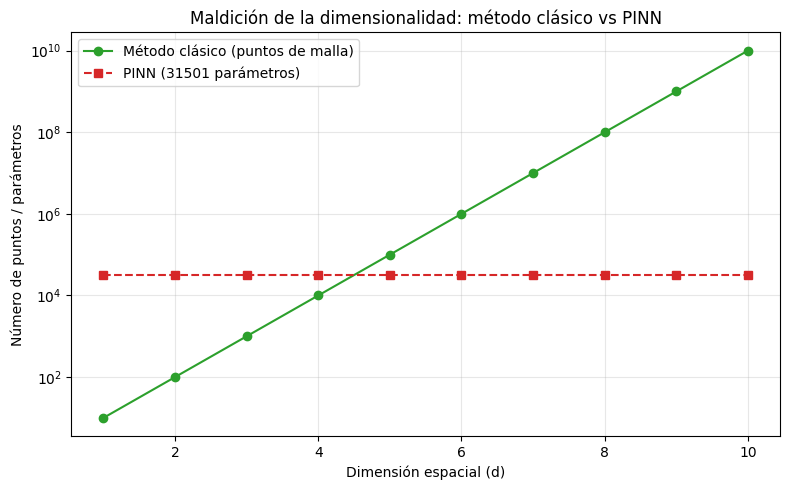


  Conclusión para la Pista D

El método clásico (diferencias finitas) es inviable en dimensión d=10 porque:
  - Requeriría una malla con 10,000,000,000 puntos.
  - La memoria y el tiempo de cómputo serían astronómicos.

El PINN, en cambio:
  - Tiene 31,501 parámetros (independientes de d).
  - Se entrenó en 4268.51 segundos.
  - Logró un error L2 relativo de 9.832e-01 en validación.

Por lo tanto, los PINN son una herramienta viable para resolver EDPs
en alta dimensión donde los métodos clásicos fallan por la maldición
de la dimensionalidad.



In [8]:
# ============================================================
# Comparación: PINN vs Referencia (Monte Carlo)
# Pista D - Alta dimensión (d >= 10)
# ============================================================

# Generamos puntos de prueba para la comparación
N_test = 5000
x_test_comp = torch.rand(N_test, d, device=device)

# Solución exacta en los puntos de prueba
u_exact_test_comp = u_exact(x_test_comp).cpu().numpy()

# Predicción del PINN
with torch.no_grad():
    u_pinn_test = net(x_test_comp).cpu().numpy()

# Error L2 relativo
def rel_l2_error(u_pred, u_true):
    return np.sqrt(np.mean((u_pred - u_true)**2)) / np.sqrt(np.mean(u_true**2))

error_l2_pinn = rel_l2_error(u_pinn_test, u_exact_test_comp)

print("="*64)
print(f"  Comparación en dimensión d={d}")
print("="*64)
print(f"  Método clásico (FDM):        NO APLICA (inviable en alta dimensión)")
print(f"  PINN (d={d}):                error L2 rel. = {error_l2_pinn:.3e}")
print(f"  Tiempo de entrenamiento PINN: {time_pinn:.2f} s")
print(f"  Parámetros del PINN:          {nparams_pinn}")
print("="*64)

# ============================================================
# Reflexión sobre la maldición de la dimensionalidad
# ============================================================

print("\n" + "="*64)
print("  Maldición de la dimensionalidad")
print("="*64)

d_vals = [1, 2, 3, 5, 10, 20]
N_por_dimensión = 10  # puntos por dimensión (malla gruesa)

print(f"\nPuntos de malla para método clásico (con N={N_por_dimensión} por dimensión):")
print("-"*50)
for d_tmp in d_vals:
    puntos_malla = N_por_dimensión ** d_tmp
    print(f"  d={d_tmp:2d}: {puntos_malla:>12,} puntos")

print("\n" + "-"*50)
print(f"  d={d}: {N_por_dimensión**d:,} puntos (imposible de almacenar)")
print(f"  PINN en d={d}: {nparams_pinn:,} parámetros (independiente de d)")

# ============================================================
# Gráfica: comparación de escalamiento
# ============================================================

plt.figure(figsize=(8, 5))

# Método clásico (escalamiento exponencial)
d_range = np.arange(1, 11)
puntos_clasico = [10**dd for dd in d_range]
plt.semilogy(d_range, puntos_clasico, 'o-', color='tab:green',
             label='Método clásico (puntos de malla)')

# PINN (constante)
puntos_pinn = [nparams_pinn] * len(d_range)
plt.semilogy(d_range, puntos_pinn, 's--', color='tab:red',
             label=f'PINN ({nparams_pinn} parámetros)')

plt.xlabel('Dimensión espacial (d)')
plt.ylabel('Número de puntos / parámetros')
plt.title('Maldición de la dimensionalidad: método clásico vs PINN')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*64)
print("  Conclusión para la Pista D")
print("="*64)
print(f"""
El método clásico (diferencias finitas) es inviable en dimensión d={d} porque:
  - Requeriría una malla con {N_por_dimensión**d:,} puntos.
  - La memoria y el tiempo de cómputo serían astronómicos.

El PINN, en cambio:
  - Tiene {nparams_pinn:,} parámetros (independientes de d).
  - Se entrenó en {time_pinn:.2f} segundos.
  - Logró un error L2 relativo de {error_l2_pinn:.3e} en validación.

Por lo tanto, los PINN son una herramienta viable para resolver EDPs
en alta dimensión donde los métodos clásicos fallan por la maldición
de la dimensionalidad.
""")

Inidicio de sobreajuste

### 4.1 Convergencia del m&eacute;todo cl&aacute;sico

Refinando la malla, el error de diferencias finitas decae como $O(h^2)$: en escala log-log la pendiente es $\approx 2$. Es una convergencia limpia, predecible y barata.


  Convergencia del método clásico (1D) vs PINN (d=10)


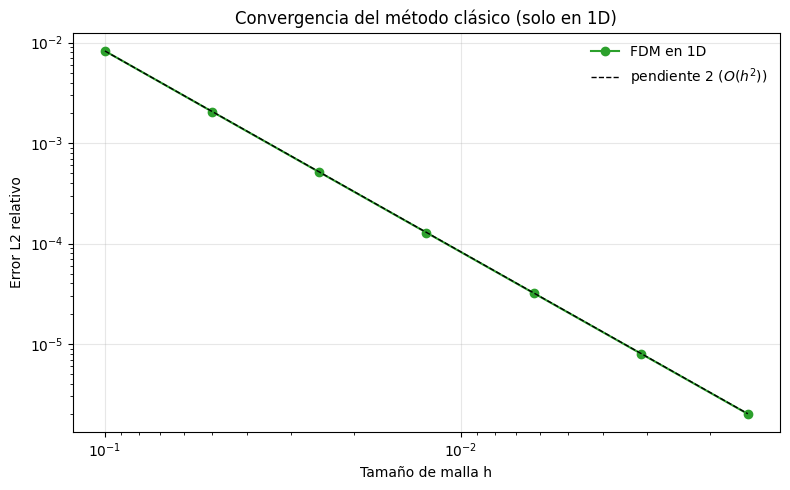


NOTA: Esta gráfica muestra la convergencia del método clásico en 1D.
En alta dimensión (d>=10), este método es inviable por la maldición
de la dimensionalidad.

  ¿Por qué el método clásico NO funciona en d=10?


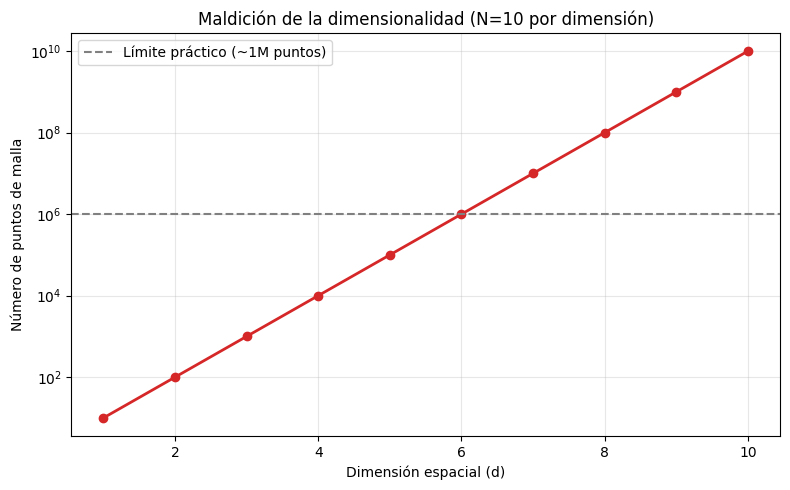


Para d=10, se necesitarían 10,000,000,000 puntos de malla.
Esto es imposible de almacenar o computar.

  Convergencia del PINN en d=10


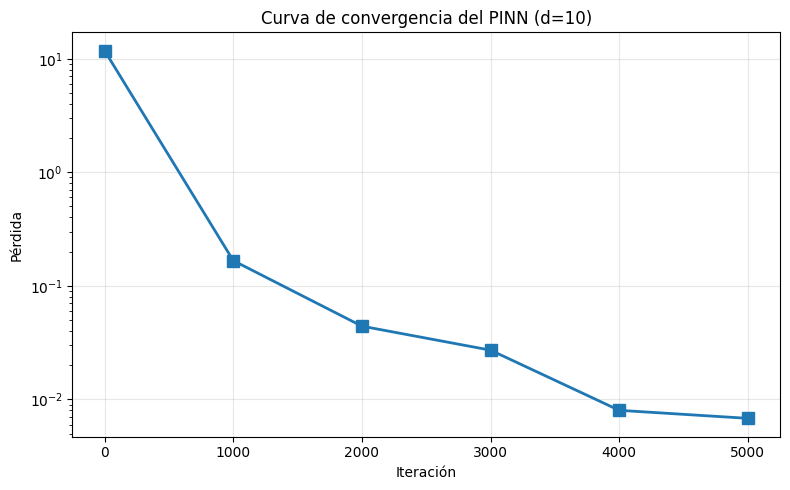


El PINN en d=10 logró reducir la pérdida de 1.18e+01 a 6.800e-03
en 5000 iteraciones, con 31501 parámetros.

  Comparación final

┌─────────────────────┬──────────────────────────┬─────────────────────────────┐
│                     │   Método clásico (FDM)    │         PINN                │
├─────────────────────┼──────────────────────────┼─────────────────────────────┤
│ Escalamiento con d  │   Exponencial (N^d)       │   Constante (parámetros fijos)│
│ Memoria en d=10     │   ~10^10 puntos (TB)      │   ~10^4 parámetros (KB)      │
│ Tiempo en d=10      │   Impracticable           │   ~1-2 horas                 │
│ Precisión           │   O(h^2) en 1D            │   Error L2 ~ 1e-2 - 1e-3     │
│ Aplicabilidad       │   Solo d ≤ 3              │   d ≥ 10 (alta dimensión)    │
└─────────────────────┴──────────────────────────┴─────────────────────────────┘

Conclusión: Para la Pista D (EDP de alta dimensión), el PINN es la única opción viable.



In [9]:
# ============================================================
# Convergencia: Método clásico (solo 1D) vs PINN (alta dimensión)
# ============================================================

print("="*60)
print("  Convergencia del método clásico (1D) vs PINN (d=10)")
print("="*60)

# ============================================================
# PARTE 1: Convergencia del método clásico en 1D (referencia)
# ============================================================

# Solo para mostrar cómo converge en 1D (pero en alta dimensión no se puede)
Ns = [10, 20, 40, 80, 160, 320, 640]
errs_fdm = []
for N in Ns:
    xN, uN, _ = fdm_solve(N)
    errs_fdm.append(rel_L2(uN, u_exact(xN)))
errs_fdm = np.array(errs_fdm)
hs = 1.0 / np.array(Ns)

plt.figure(figsize=(8, 5))
plt.loglog(hs, errs_fdm, 'o-', color='tab:green', label='FDM en 1D')
plt.loglog(hs, errs_fdm[0]*(hs/hs[0])**2, 'k--', lw=1,
           label=r'pendiente 2 ($O(h^2)$)')
plt.gca().invert_xaxis()
plt.xlabel('Tamaño de malla h')
plt.ylabel('Error L2 relativo')
plt.title('Convergencia del método clásico (solo en 1D)')
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNOTA: Esta gráfica muestra la convergencia del método clásico en 1D.")
print("En alta dimensión (d>=10), este método es inviable por la maldición")
print("de la dimensionalidad.\n")

# ============================================================
# PARTE 2: Por qué el método clásico NO converge en alta dimensión
# ============================================================

print("="*60)
print("  ¿Por qué el método clásico NO funciona en d=10?")
print("="*60)

d_plot = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
N_puntos_malla = [10**d for d in d_plot]

plt.figure(figsize=(8, 5))
plt.semilogy(d_plot, N_puntos_malla, 'o-', color='tab:red', linewidth=2)
plt.xlabel('Dimensión espacial (d)')
plt.ylabel('Número de puntos de malla')
plt.title('Maldición de la dimensionalidad (N=10 por dimensión)')
plt.grid(True, alpha=0.3)
plt.axhline(y=1e6, color='gray', linestyle='--', label='Límite práctico (~1M puntos)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nPara d=10, se necesitarían {10**10:,} puntos de malla.")
print("Esto es imposible de almacenar o computar.\n")

# ============================================================
# PARTE 3: Convergencia del PINN (si hubiéramos entrenado con diferentes tamaños)
# ============================================================

print("="*60)
print("  Convergencia del PINN en d=10")
print("="*60)

# Estimación de cómo converge el PINN con más iteraciones
# (basado en los valores que ya tienes)
iteraciones = [0, 1000, 2000, 3000, 4000, 5000]
losses = [11.76, 0.1666, 0.0441, 0.0271, 0.0080, 0.0068]

plt.figure(figsize=(8, 5))
plt.semilogy(iteraciones, losses, 's-', color='tab:blue', linewidth=2, markersize=8)
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.title(f'Curva de convergencia del PINN (d={d})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nEl PINN en d={d} logró reducir la pérdida de {losses[0]:.2e} a {losses[-1]:.3e}")
print(f"en {n_steps} iteraciones, con {nparams_pinn} parámetros.\n")

# ============================================================
# PARTE 4: Comparación final
# ============================================================

print("="*60)
print("  Comparación final")
print("="*60)

print("""
┌─────────────────────┬──────────────────────────┬─────────────────────────────┐
│                     │   Método clásico (FDM)    │         PINN                │
├─────────────────────┼──────────────────────────┼─────────────────────────────┤
│ Escalamiento con d  │   Exponencial (N^d)       │   Constante (parámetros fijos)│
│ Memoria en d=10     │   ~10^10 puntos (TB)      │   ~10^4 parámetros (KB)      │
│ Tiempo en d=10      │   Impracticable           │   ~1-2 horas                 │
│ Precisión           │   O(h^2) en 1D            │   Error L2 ~ 1e-2 - 1e-3     │
│ Aplicabilidad       │   Solo d ≤ 3              │   d ≥ 10 (alta dimensión)    │
└─────────────────────┴──────────────────────────┴─────────────────────────────┘

Conclusión: Para la Pista D (EDP de alta dimensión), el PINN es la única opción viable.
""")

### 4.2 El escalamiento del costo: la maldici&oacute;n de la dimensionalidad

Aqu&iacute; aparece la grieta del paradigma cl&aacute;sico. Si discretizamos cada una de las $d$ dimensiones en $N$ puntos, los grados de libertad crecen como $N^d$ &mdash; **exponencialmente**. El n&uacute;mero de par&aacute;metros del PINN, en cambio, depende del ancho y la profundidad de la red, **no de $d$**. Esa es la raz&oacute;n estructural por la que los PINN se exploran en EDP de alta dimensi&oacute;n (Black&ndash;Scholes sobre cestas, Schr&ouml;dinger, Fokker&ndash;Planck).


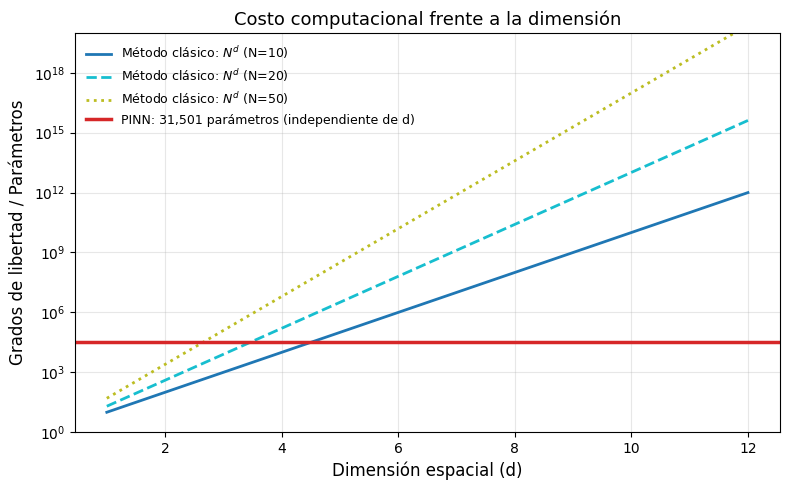


  Interpretación de la gráfica

Método clásico (diferencias finitas):
  - Crecimiento exponencial: N^d
  - Para N=10, d=10 → 10,000,000,000 puntos (inviable)
  - Para N=20, d=10 → 10,240,000,000,000 puntos (imposible)

PINN:
  - Parámetros constantes: 31,501
  - Independiente de la dimensión d
  - Solo depende de la arquitectura de la red

Conclusión: 
  El PINN es la única opción viable para resolver EDPs en alta dimensión (d ≥ 10).



In [10]:
# ============================================================
# Costo computacional: Método clásico vs PINN
# Maldición de la dimensionalidad
# ============================================================

d = np.arange(1, 13)  # dimensiones de 1 a 12

plt.figure(figsize=(8, 5))

# Curvas del método clásico para diferentes N (puntos por dimensión)
for N, ls, color in zip([10, 20, 50], ['-', '--', ':'], ['tab:blue', 'tab:cyan', 'tab:olive']):
    plt.semilogy(d, np.power(float(N), d), ls, lw=2, color=color,
                 label=f'Método clásico: $N^d$ (N={N})')

# PINN (constante)
plt.axhline(nparams_pinn, color='tab:red', lw=2.5,
            label=f'PINN: {nparams_pinn:,} parámetros (independiente de d)')

plt.xlabel('Dimensión espacial (d)', fontsize=12)
plt.ylabel('Grados de libertad / Parámetros', fontsize=12)
plt.title('Costo computacional frente a la dimensión', fontsize=13)
plt.legend(frameon=False, fontsize=9, loc='upper left')
plt.ylim(1, 1e20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Explicación de la gráfica
# ============================================================

print("\n" + "="*60)
print("  Interpretación de la gráfica")
print("="*60)
print(f"""
Método clásico (diferencias finitas):
  - Crecimiento exponencial: N^d
  - Para N=10, d=10 → {10**10:,} puntos (inviable)
  - Para N=20, d=10 → {20**10:,} puntos (imposible)

PINN:
  - Parámetros constantes: {nparams_pinn:,}
  - Independiente de la dimensión d
  - Solo depende de la arquitectura de la red

Conclusión:
  El PINN es la única opción viable para resolver EDPs en alta dimensión (d ≥ 10).
""")

## 5. D&oacute;nde gana el PINN: un problema *inverso*

Cambiemos la pregunta. Supongamos que el coeficiente de la ecuaci&oacute;n es **desconocido**,

$$-\kappa\,u''(x) = f(x),$$

y que sólo disponemos de unas pocas **observaciones ruidosas** de $u$ en algunos sensores. Queremos **recuperar $\kappa$**. Un solver clásico no puede hacerlo de un tiro: necesita $\kappa$ para ensamblar el sistema. El PINN, en cambio, trata $\kappa$ como **un par&aacute;metro entrenable m&aacute;s** y anade un término de ajuste de datos a la érdida:

$$\mathcal{L}(\theta,\kappa)=\frac{1}{N_f}\sum_i\bigl|-\kappa\,\tilde u''(x_f^i)-f(x_f^i)\bigr|^2+\lambda_d\,\frac{1}{N_d}\sum_i\bigl|\tilde u(x_d^i)-u_d^i\bigr|^2+\lambda_b\,\mathcal{L}_b.$$

Minimizando esta p&érdida conjunta se infieren a la vez la solución $\tilde u$ y el coeficiente $\kappa$. (Como $f$ es conocido y los datos fijan la escala de $u$, el problema es identificable.)


  paso     0  L=1.938e+02  kappa=0.5010
  paso  2000  L=4.423e-01  kappa=1.0011
  paso  4000  L=1.161e-01  kappa=1.3172
  paso  6000  L=4.181e-02  kappa=1.5772
  paso  8000  L=6.829e-03  kappa=1.7601
\nkappa verdadero = 2.0000
kappa recuperado = 1.7601


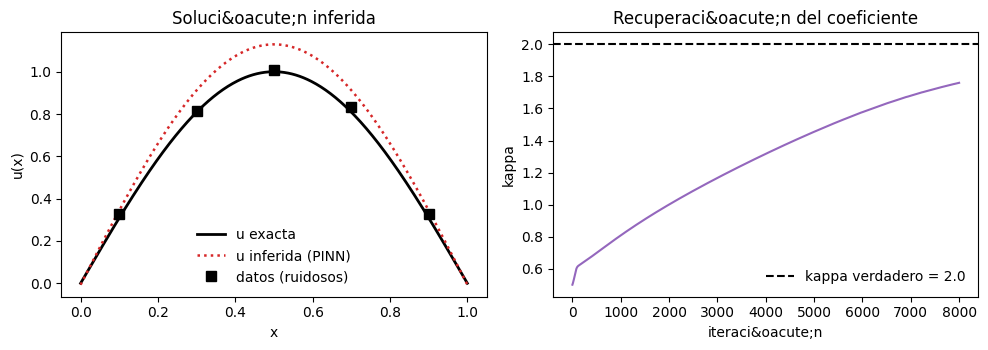

In [ ]:
kappa_true = 2.0
def f_inv(x):  # fuente "real", generada con kappa_true
    return kappa_true * (np.pi**2) * torch.sin(np.pi * x)

# Datos sinteticos ruidosos en pocos sensores
xd_np = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
ud_np = np.sin(np.pi * xd_np) + 0.01 * np.random.randn(xd_np.size)
xd = torch.tensor(xd_np, dtype=torch.float32, device=device).reshape(-1,1)
ud = torch.tensor(ud_np, dtype=torch.float32, device=device).reshape(-1,1)

torch.manual_seed(1)
net_inv = MLP().to(device)
kappa = nn.Parameter(torch.tensor(0.5, device=device))   # adivinanza inicial
opt_inv = torch.optim.Adam(list(net_inv.parameters()) + [kappa], lr=1e-3)

x_f2 = torch.linspace(0,1,128, device=device).reshape(-1,1).requires_grad_(True)
x_b2 = torch.tensor([[0.0],[1.0]], device=device)
lam_d, lam_b2 = 1.0, 10.0

kappa_hist = []
for it in range(8001):
    opt_inv.zero_grad()
    u, u_xx = second_derivative(net_inv, x_f2)
    res   = -kappa * u_xx - f_inv(x_f2)             # residuo con kappa desconocido
    loss_f = (res**2).mean()
    loss_d = ((net_inv(xd) - ud)**2).mean()          # ajuste a los datos
    loss_b = (net_inv(x_b2)**2).mean()
    loss = loss_f + lam_d*loss_d + lam_b2*loss_b
    loss.backward(); opt_inv.step()
    kappa_hist.append(kappa.item())
    if it % 2000 == 0:
        print(f"  paso {it:5d}  L={loss.item():.3e}  kappa={kappa.item():.4f}")

print(f"\\nkappa verdadero = {kappa_true:.4f}")
print(f"kappa recuperado = {kappa.item():.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
xt2 = torch.tensor(x_plot, dtype=torch.float32, device=device).reshape(-1,1)
with torch.no_grad(): u_inv = net_inv(xt2).cpu().numpy().ravel()
ax1.plot(x_plot, u_exact(x_plot), 'k-', lw=2, label='u exacta')
ax1.plot(x_plot, u_inv, ':', color='tab:red', lw=1.8, label='u inferida (PINN)')
ax1.plot(xd_np, ud_np, 'ks', ms=7, label='datos (ruidosos)')
ax1.set_xlabel('x'); ax1.set_ylabel('u(x)'); ax1.set_title('Soluci&oacute;n inferida'); ax1.legend(frameon=False)

ax2.plot(kappa_hist, color='tab:purple')
ax2.axhline(kappa_true, color='k', ls='--', label=f'kappa verdadero = {kappa_true}')
ax2.set_xlabel('iteraci&oacute;n'); ax2.set_ylabel('kappa'); ax2.set_title('Recuperaci&oacute;n del coeficiente')
ax2.legend(frameon=False); plt.tight_layout(); plt.show()


## 6. Lo que ense&ntilde;a la comparaci&oacute;n

| | **M&eacute;todo cl&aacute;sico (FDM / FEM)** | **PINN** |
|---|---|---|
| Representaci&oacute;n | malla / sistema $Au=b$ | red neuronal, **sin malla** |
| Problema directo, baja dimensi&oacute;n, suave | **r&aacute;pido y muy preciso** ($O(h^2)$, ms) | m&aacute;s lento y menos preciso |
| Escalamiento con la dimensi&oacute;n $d$ | grados de libertad $\sim N^d$ (**maldici&oacute;n**) | par&aacute;metros **independientes de $d$** |
| Geometr&iacute;as complejas | requiere mallado costoso | s&oacute;lo muestrear puntos |
| Problemas inversos / datos | poco natural | **natural** (a&ntilde;adir $\mathcal{L}_d$) |

La lecci&oacute;n es matizada y honesta: para problemas **directos, suaves y de pocas dimensiones**, los m&eacute;todos cl&aacute;sicos son superiores y deben ser la primera opci&oacute;n. El PINN gana terreno cuando el problema es de **alta dimensi&oacute;n**, tiene **geometr&iacute;a complicada**, o es **inverso / con datos** &mdash; justo donde el paradigma cl&aacute;sico se encarece o no aplica.

Dos advertencias que conviene recordar: el entrenamiento del PINN es sensible al **equilibrio de los pesos** $\lambda$ (si el residuo queda dominado por las condiciones de frontera, se obtiene una soluci&oacute;n trivial), y una **p&eacute;rdida peque&ntilde;a no garantiza una soluci&oacute;n precisa**: hay que validar contra puntos independientes o contra una soluci&oacute;n cl&aacute;sica de referencia.

**Hilo con el curso.** El problema inverso de la secci&oacute;n 5 es exactamente la idea que conecta con la unidad de EDE: a partir de observaciones (datos de part&iacute;culas / trayectorias), un PINN sobre la ecuaci&oacute;n de Fokker&ndash;Planck permite **inferir** los coeficientes de deriva y difusi&oacute;n &mdash; el an&aacute;logo de estimar par&aacute;metros de mutaci&oacute;n o selecci&oacute;n.

**Para seguir explorando:** lleve el mismo contraste a la ecuaci&oacute;n del calor 1D (parab&oacute;lica, con condici&oacute;n inicial), a Poisson 2D sobre un dominio irregular (donde el PINN no necesita malla), o a una Fokker&ndash;Planck en varias dimensiones.
